In [1]:
import random
import math
import numpy as np
import os
from PIL import Image

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

import matplotlib.pyplot as plt

In [2]:
os.makedirs('model/', exist_ok=True)

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
cuDNN version: 90100
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.44 GB


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Augmentation & Normalize

In [5]:
transform = transforms.Compose([
        transforms.Resize(512),              # Меньшая сторона = 512
        transforms.CenterCrop(512), 
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        )
    ])


### Train dataset & dataloader

In [6]:
train_dataset = torchvision.datasets.ImageFolder(
    root='data/train',
    transform=transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=16,          
    shuffle=True,
    num_workers=2,          
    pin_memory=True,        
    persistent_workers=True 
)

print(f"Классы: {train_dataset.classes}")
print(f"Class to idx: {train_dataset.class_to_idx}")
print(f"Размер датасета: {len(train_dataset)}")

Классы: ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lisa_simpson', 'marge_simpson', 'mayor_quimby', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'principal_skinner', 'sideshow_bob']
Class to idx: {'abraham_grampa_simpson': 0, 'apu_nahasapeemapetilon': 1, 'bart_simpson': 2, 'charles_montgomery_burns': 3, 'chief_wiggum': 4, 'comic_book_guy': 5, 'edna_krabappel': 6, 'homer_simpson': 7, 'kent_brockman': 8, 'krusty_the_clown': 9, 'lenny_leonard': 10, 'lisa_simpson': 11, 'marge_simpson': 12, 'mayor_quimby': 13, 'milhouse_van_houten': 14, 'moe_szyslak': 15, 'ned_flanders': 16, 'nelson_muntz': 17, 'principal_skinner': 18, 'sideshow_bob': 19}
Размер датасета: 19548


### Valid dataset & dataloader

In [7]:
class Valid_Dataset(Dataset):
    def __init__(self, path_dir='./data/valid', transforms=transform, classes=train_dataset.classes):
        self.samples = []
        self.class_to_idx = {}  
        
        for file in sorted(os.listdir(path_dir)):
            if file.endswith('.jpg') or file.endswith('.png'):
                for i in range(len(classes)):
                    if classes[i] in file:
                        self.class_to_idx[classes[i]] = i
                        self.samples.append((os.path.join(path_dir, file), classes[i], i)) # [(path, class, idx_class), ...]
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        image_path, class_name, idx_class = self.samples[idx]
        img = Image.open(image_path).convert('RGB')
        img = transform(img)
        return img, torch.tensor(idx_class, dtype=torch.long)

valid_dataset = Valid_Dataset()

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=8,          
    shuffle=False,
    num_workers=2,          
    pin_memory=True,        
    persistent_workers=True 
)

print(f"Class to idx: {valid_dataset.class_to_idx}")
print(f"Размер датасета: {len(valid_dataset)}")

Class to idx: {'abraham_grampa_simpson': 0, 'apu_nahasapeemapetilon': 1, 'bart_simpson': 2, 'charles_montgomery_burns': 3, 'chief_wiggum': 4, 'comic_book_guy': 5, 'edna_krabappel': 6, 'homer_simpson': 7, 'kent_brockman': 8, 'krusty_the_clown': 9, 'lenny_leonard': 10, 'lisa_simpson': 11, 'marge_simpson': 12, 'mayor_quimby': 13, 'milhouse_van_houten': 14, 'moe_szyslak': 15, 'ned_flanders': 16, 'nelson_muntz': 17, 'principal_skinner': 18, 'sideshow_bob': 19}
Размер датасета: 990


### Test dataset & dataloader


In [8]:
test_dataset = torchvision.datasets.ImageFolder(
    root='data/test',
    transform=transform,
)

test_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
)

print(f"Class to idx: {test_dataset.class_to_idx}")
print(f"Размер датасета: {len(test_dataset)}")

Class to idx: {'abraham_grampa_simpson': 0, 'apu_nahasapeemapetilon': 1, 'bart_simpson': 2, 'charles_montgomery_burns': 3, 'chief_wiggum': 4, 'comic_book_guy': 5, 'edna_krabappel': 6, 'homer_simpson': 7, 'kent_brockman': 8, 'krusty_the_clown': 9, 'lenny_leonard': 10, 'lisa_simpson': 11, 'marge_simpson': 12, 'mayor_quimby': 13, 'milhouse_van_houten': 14, 'moe_szyslak': 15, 'ned_flanders': 16, 'nelson_muntz': 17, 'principal_skinner': 18, 'sideshow_bob': 19}
Размер датасета: 990


### Functions for saving weights of model and checkpoins of learning

In [9]:
def save_checkpoint(model, optimizer, train_losses=[], val_losses=[], epochs_list=[], filename='model/checkpoint.pth'):
    """
    Сохраняет данные о модели и оптимизаторе, а также train_losses и val_losses на протяжении всего цикла обучения
    """

    checkpoint = {
        'epoch': len(epochs_list),
        'epochs_list': epochs_list,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,           
        'val_losses': val_losses 
    }
    torch.save(checkpoint, filename)

def load_checkpoint(filename, model, optimizer, device):
    """
    Загружает состояние и возвращает номер эпохи, а также train_losses и val_losses всего цикла обучения для дальнейшей визуализации
    """

    checkpoint = torch.load(filename, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    print(f"✓ Загружено из эпохи {checkpoint['epoch']}, train_loss: {checkpoint['train_losses'][-1]:.4f}, val_loss: {checkpoint['val_losses'][-1]:.4f}")
    return checkpoint['epoch'], checkpoint['train_losses'], checkpoint['val_losses'], checkpoint['epochs_list']

## Model 

In [10]:
class NN(nn.Module): #img_size = 512x512
    def __init__(self, num_classes):
        super().__init__()
        
        self.Squeez = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4), #512x512 -> 128x128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4), #128x128 -> 32x32
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4), #32x32 -> 8x8
            nn.Flatten(),
        )
        
        # 64x64 -> 16x16
        self.Choose = nn.Sequential(
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5), # откидываем часть, чтобы избежать переобучения
            nn.Linear(256, num_classes)            
        )
    
    def forward(self, x):
        x = self.Squeez(x)
        x = self.Choose(x)
        return x

In [11]:
def train_step(model, optimizer, dataloader, criterion, device):
    """ 
    Функция для цикла обучения 
    """
    
    model.train()
    running_loss = 0.
    correct = 0
    total = 0
    
    for image, idx_class in dataloader:
        image = image.to(device)
        idx_class = idx_class.to(device)
        
        optimizer.zero_grad()
        outputs = model(image)
        
        loss = criterion(outputs, idx_class)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += idx_class.size(0)
        correct += (predicted == idx_class).sum().item()
    
    train_loss = running_loss / len(dataloader)
    accuracy = 100 * correct / total
    return train_loss, accuracy

In [12]:
def validate(model, criterion, dataloader):
    """ 
    Функция для валидационного цикла
    """
    
    model.eval()
    total_loss = 0
    correct = 0
    
    with torch.no_grad():
        for image, idx_class in dataloader:
            image = image.to(device)
            idx_class = idx_class.to(device)
            
            outputs = model(image)
            loss = criterion(outputs, idx_class)
            
            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == idx_class).sum().item()
            
    return total_loss / len(dataloader), correct / len(dataloader.dataset)

In [13]:
def train_system(train_dataloader, val_dataloader,  epochs=20, resume_from='model/checkpoint.pth'):
    """
    Цикл обучения
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
    
    num_classes = len(train_dataloader.dataset.classes)
    print(f"Количество классов: {num_classes}")
    
    model = NN(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        params=model.parameters(),
        lr=0.0015,
        weight_decay=1e-4, 
        betas=(0.9, 0.999)
    )
    
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    best_loss = float('inf')
    start_epoch = 0
    epochs_list = []

    if resume_from and os.path.exists(resume_from):
        print(f"Продолжаем обучение из {resume_from}")
        start_epoch, train_losses, val_losses, epochs_list = load_checkpoint(resume_from, model, optimizer, device)
        start_epoch += 1
    
    for i in range(start_epoch, epochs):
        train_loss, train_acc = train_step(model, optimizer, train_dataloader, criterion, device)
        val_loss, val_acc = validate(model, criterion, val_dataloader)

        epochs_list.append(i)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch: {i+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%\n")
        
        if (i + 1) % 5 == 0:
            save_checkpoint(model, optimizer, train_losses, val_losses, epochs_list)
        
        if train_loss < best_loss:
            best_loss = train_loss
            save_checkpoint(model, optimizer, train_loss, val_loss, epochs_list, 'model/checkpoint_best.pth')
            torch.save(model.state_dict(), 'model/model_best.pth')
    
    return train_losses, val_losses, epochs_list, model


## Обучение модели

In [14]:
train_losses, val_losses, epochs_list, model = train_system(train_dataloader, valid_dataloader, epochs=40)

Training on: cuda
Количество классов: 20
Продолжаем обучение из model/checkpoint.pth
✓ Загружено из эпохи 24, train_loss: 0.2685, val_loss: 0.1437
Epoch: 26/40, Train Loss: 0.2619, Train Acc: 92.32%
Val Loss: 0.1521, Val Acc: 0.95%

Epoch: 27/40, Train Loss: 0.2473, Train Acc: 92.56%
Val Loss: 0.2252, Val Acc: 0.94%

Epoch: 28/40, Train Loss: 0.2553, Train Acc: 92.39%
Val Loss: 0.2259, Val Acc: 0.94%

Epoch: 29/40, Train Loss: 0.2612, Train Acc: 92.34%
Val Loss: 0.1323, Val Acc: 0.96%

Epoch: 30/40, Train Loss: 0.2279, Train Acc: 93.29%
Val Loss: 0.1336, Val Acc: 0.96%

Epoch: 31/40, Train Loss: 0.2418, Train Acc: 92.81%
Val Loss: 0.1308, Val Acc: 0.96%

Epoch: 32/40, Train Loss: 0.2398, Train Acc: 92.86%
Val Loss: 0.1491, Val Acc: 0.96%

Epoch: 33/40, Train Loss: 0.2195, Train Acc: 93.38%
Val Loss: 0.0869, Val Acc: 0.97%

Epoch: 34/40, Train Loss: 0.2385, Train Acc: 93.13%
Val Loss: 0.0864, Val Acc: 0.97%

Epoch: 35/40, Train Loss: 0.2099, Train Acc: 93.70%
Val Loss: 0.1128, Val Acc: 

## Отображение результатов обучения
1. График Loss
2. TSNE
3. Дистанция между парами изображений
4. Определения класса по изображению

#### 1. График Loss

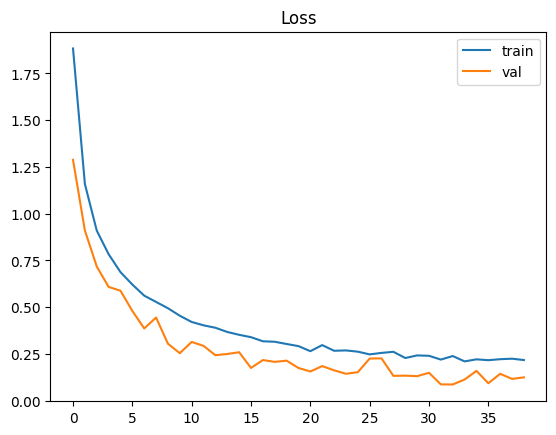

In [15]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

#### 2. TSNE

In [16]:
from sklearn.manifold import TSNE


def vizual_tSNE(model, tsne_loader, n_samples=200, device='cuda'):
    """
    Визуализация эмбеддингов модели с помощью t-SNE
    """
    model.eval()
    
    embeddings = []
    label_ids = []
    samples_collected = 0
    
    with torch.no_grad():
        for image, idx_class in tsne_loader:
            if samples_collected >= n_samples:
                break
            
            image = image.to(device)
            idx_class = idx_class.to(device)
            
            outputs = model(image)
            
            embeddings.append(outputs.cpu().numpy())
            label_ids.append(idx_class.cpu().numpy())
            
            samples_collected += image.size(0)
    
    embeddings = np.vstack(embeddings)[:n_samples]  # [n_samples, num_classes]
    label_ids = np.concatenate(label_ids)[:n_samples]  # [n_samples]
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(7, 5))
    
    unique_labels = np.unique(label_ids)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    
    for idx, label in enumerate(unique_labels):
        mask = label_ids == label
        class_name = None
        for key, val in tsne_loader.dataset.class_to_idx.items():
            if val == label:
                class_name = key
                break
        
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   c=[colors[idx]], 
                   label=f'{class_name} ({label})', 
                   s=50, 
                   alpha=0.7,
                   edgecolors='w',
                   linewidth=0.5)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class', fontsize=8)
    plt.title('t-SNE: Кластеры эмбеддингов по классам', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

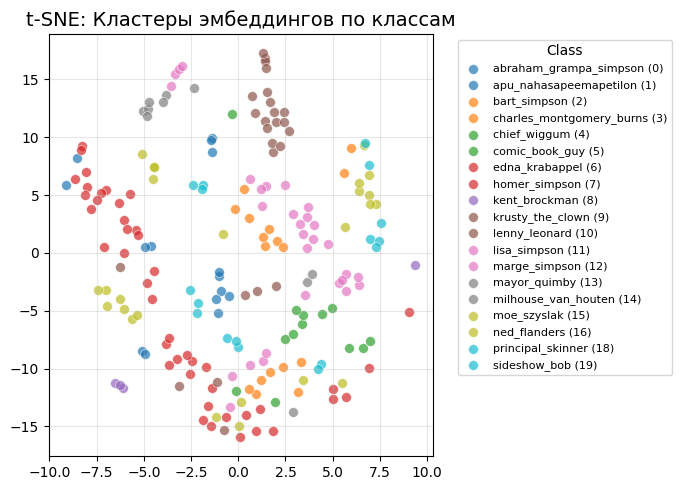

In [17]:
vizual_tSNE(model, test_dataloader)

#### 3. Дистанция между парами изображений

In [18]:
def valid_step_on_10(model, pair_loader, n_samples=10):
    model.eval()

    images = []    
    embeddings = []
    label_ids = []
    
    with torch.no_grad():
        for i, (image, idx_class) in enumerate(pair_loader):
            if i >= n_samples:
                break
            
            image = image.to(device)
            idx_class = idx_class.to(device)
            
            outputs = model(image)
            
            img_np = image[0].cpu().numpy()
            # (C, H, W) -> (H, W, C)
            if img_np.shape[0] == 3:
                img_np = np.transpose(img_np, (1, 2, 0))

            images.append(img_np)
            embeddings.append(outputs[0].cpu().numpy())
            label_ids.append(idx_class[0].item())

    embeddings = np.array(embeddings)
    label_ids = np.array(label_ids)
    
    plt.figure(figsize=(12, 10))

    mean=(0.5, 0.5, 0.5)
    std=(0.5, 0.5, 0.5)
    
    for i in range(0, len(images) - 1, 2):
        name1, name2 = None, None
        for key, val in pair_loader.dataset.class_to_idx.items():
            if val == label_ids[i]:
                name1 = key
            if val == label_ids[i+1]:
                name2 = key
        
        image1 = images[i] * std + mean
        image2 = images[i+1] * std + mean
        # Фото 1
        plt.subplot(len(images)//2, 3, i//2 * 3 + 1)
        plt.imshow(image1)
        plt.axis('off')
        plt.title(f"Class: {name1}")
        
        # Фото 2
        plt.subplot(len(images)//2, 3, i//2 * 3 + 2)
        plt.imshow(image2)
        plt.axis('off')
        plt.title(f"Class: {name2}")
        
        emb1 = F.normalize(torch.tensor(embeddings[i]).unsqueeze(0), p=2, dim=1)
        emb2 = F.normalize(torch.tensor(embeddings[i+1]).unsqueeze(0), p=2, dim=1)
        distance = F.pairwise_distance(emb1, emb2, p=2).item()
        predicted_same = 1.0 if distance < 0.5 else 0.0
        is_correct = predicted_same == (label_ids[i] == label_ids[i+1])
        # Результат
        plt.subplot(len(images)//2, 3, i//2 * 3 + 3)
        label_str = "Один" if label_ids[i] == label_ids[i+1] else "Разные"
        pred_str = "Один" if predicted_same == 1.0 else "Разные"
        
        plt.text(0.5, 0.5, f"Дист: {distance:.3f}\nПрогноз: {pred_str}\nРеальность: {label_str}",
                bbox=dict(facecolor='green' if is_correct else 'red', alpha=0.5))
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

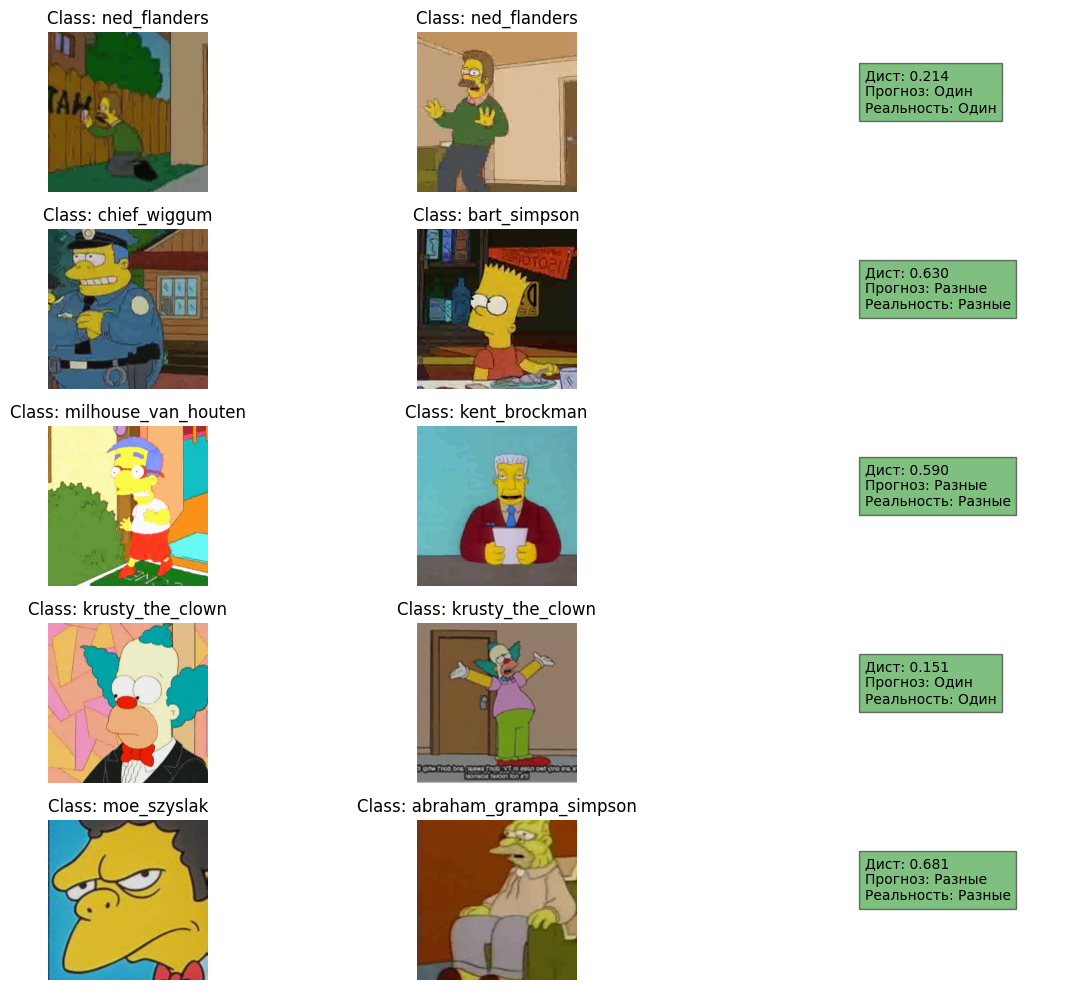

In [27]:
valid_step_on_10(model, test_dataloader)

#### 4. Определения класса по изображению

In [20]:
def detect_picture(model, loader, n_samples=5):
    images = []    
    label_ids = []
    predicted = []
    
    with torch.no_grad():
        for i, (image, idx_class) in enumerate(loader):
            if i >= n_samples:
                break
            
            image = image.to(device)
            idx_class = idx_class.to(device)
            
            outputs = model(image)
            predicted_class = outputs[0].argmax(dim=0).item()
            img_np = image[0].cpu().numpy()
            # (C, H, W) -> (H, W, C)
            if img_np.shape[0] == 3:
                img_np = np.transpose(img_np, (1, 2, 0))

            images.append(img_np)
            label_ids.append(idx_class[0].item())
            predicted.append(predicted_class)

    label_ids = np.array(label_ids)
    predicted = np.array(predicted)
    
    plt.figure(figsize=(12, 10))

    mean=(0.5, 0.5, 0.5)
    std=(0.5, 0.5, 0.5)
    
    for i in range(0, len(images), 1):
        class_name_actual = None
        predicted_name_class = None
        for key, val in loader.dataset.class_to_idx.items():
            if val == label_ids[i]:
                class_name_actual = key
            if val == predicted[i]:
                predicted_name_class = key

        image = images[i] * std + mean
        # Фото 1
        plt.subplot(5, 2, i*2 + 1)
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Class: {class_name_actual}")
        
        is_correct = predicted_name_class == class_name_actual
        plt.subplot(5, 2, i*2 + 2)
        plt.text(0.5, 0.5, f"Прогноз: {predicted_name_class}\nРеальность: {class_name_actual}",
                bbox=dict(facecolor='green' if is_correct else 'red', alpha=0.5))
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

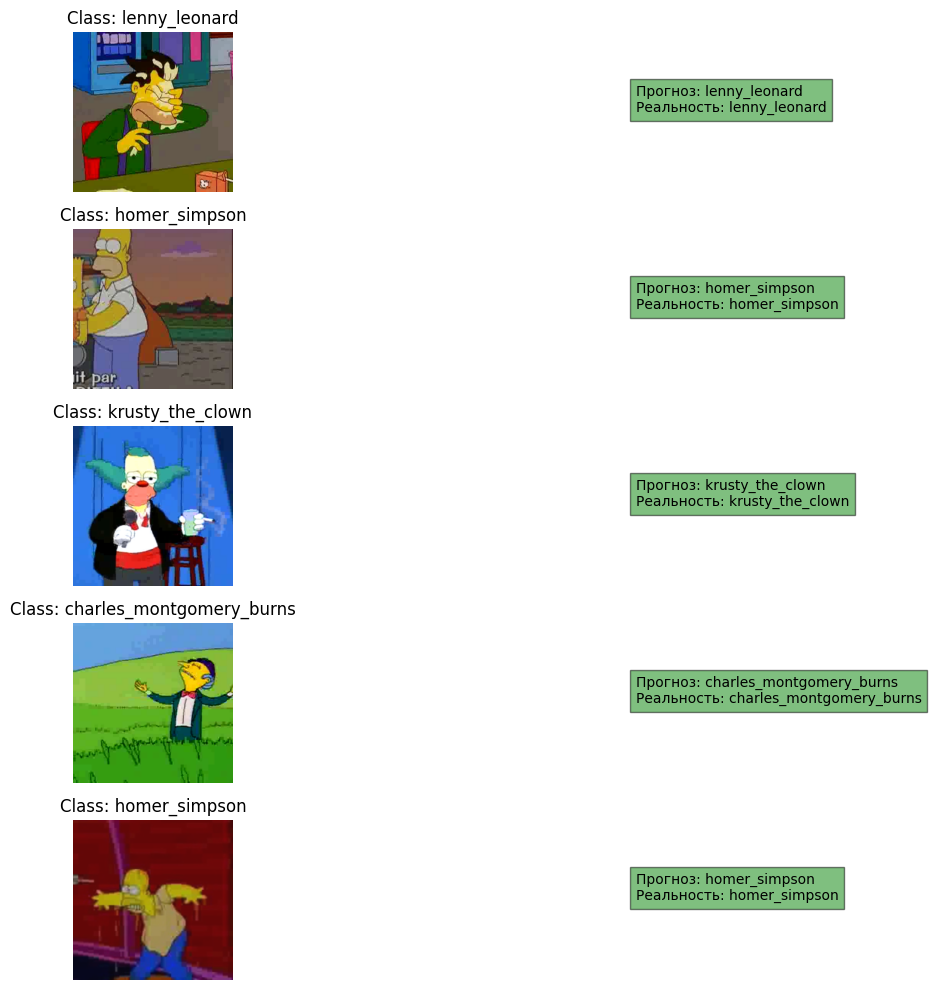

In [21]:
detect_picture(model, test_dataloader)